In [1]:
pip install pytrends 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install -U nbformat ipykernel

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install --upgrade nbformat ipython

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq
import plotly.io as pio




# setup pytrend library and define keyword


In [6]:
pytrends = TrendReq(hl='en-US', tz=360)
keyword = "bmw"

DATA REQUEST
cat= category
geo=geography

In [7]:
pytrends.build_payload([keyword],cat=0,timeframe='today 12-m',geo='',gprop='') 

country wise intrest

In [9]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keyword,ascending=False).head(15)

C:\Users\risha\AppData\Local\Temp\ipykernel_25892\4107330912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_data[keyword],y=region_data.index,palette='Blues_d')


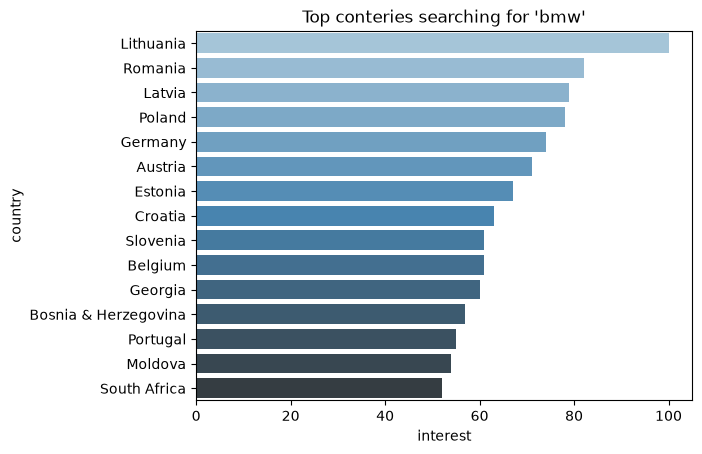

In [ ]:
plt.Figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette='Blues_d')
plt.title(f"Top conteries searching for '{keyword}'")
plt.xlabel('interest')
plt.ylabel('country')
plt.show()

world map

In [ ]:
region_data = region_data.reset_index()
fig=px.choropleth(region_data,
                  locations='geoName',
                  locationmode='country names',
                  color=keyword,
                  title=f"search Intrest for '{keyword}'by country",
                  color_continuous_scale='Blues')

fig.show()

In [ ]:
time_df =pytrends.interest_over_time()

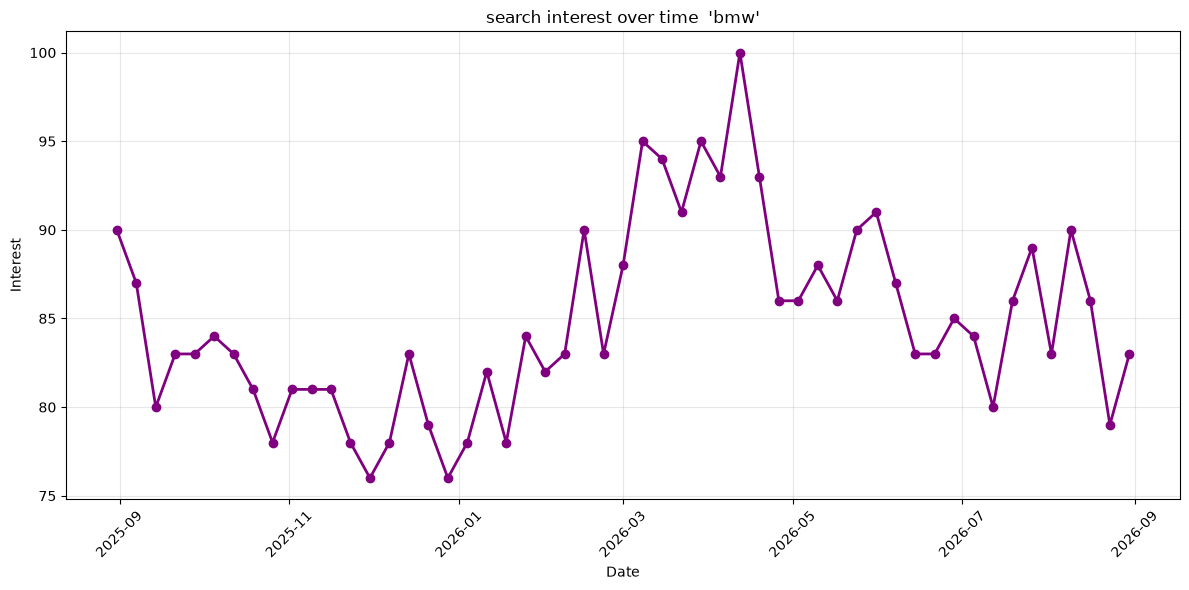

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index,time_df[keyword],marker ='o', color ='purple',linewidth=2)
plt.title(f"search interest over time  '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MULTIPLE KEYWORDS COMPARE

In [17]:
kw_list =["gemini","chatgpt","machine learning"]
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

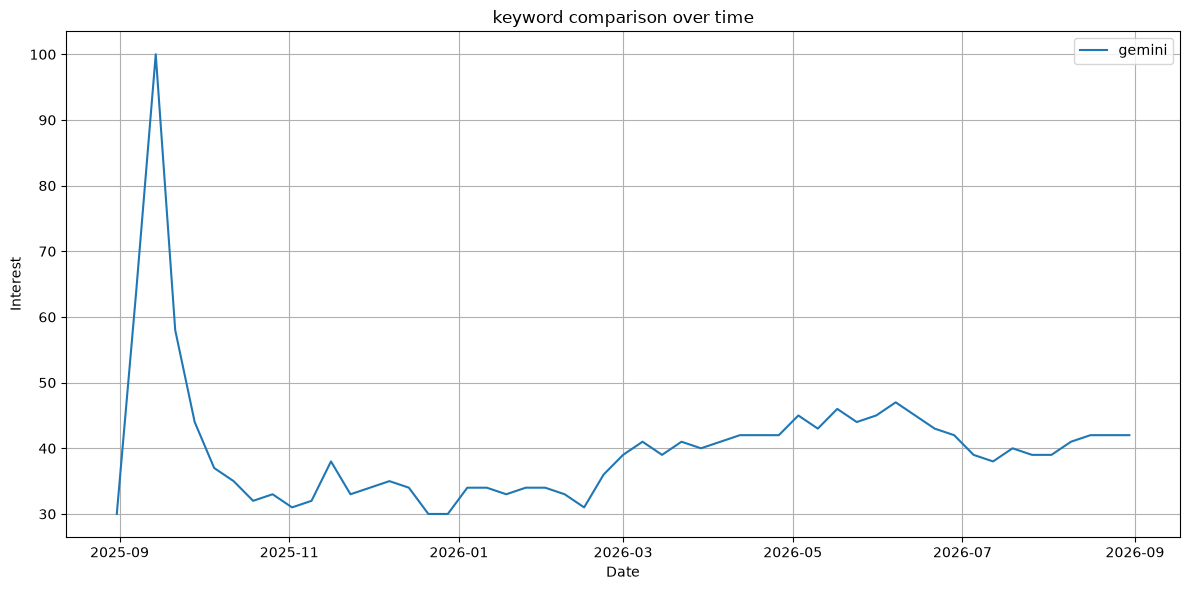

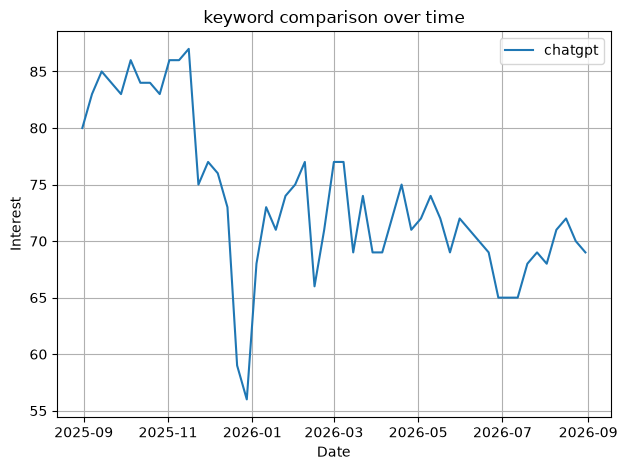

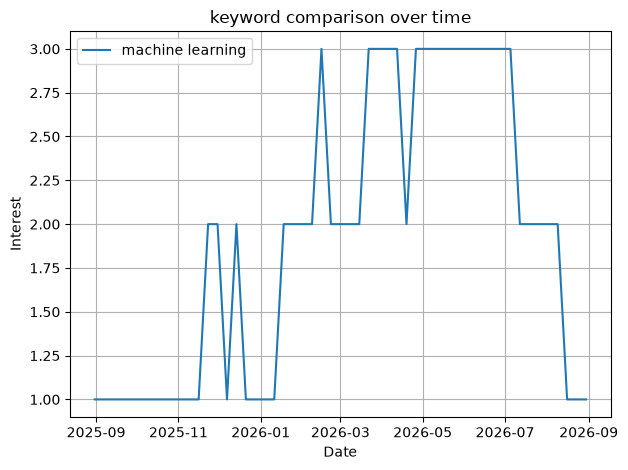

In [18]:
compare_df =pytrends.interest_over_time()
plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index,compare_df[kw],label=kw)
    plt.title("keyword comparison over time")
    plt.xlabel("Date")
    plt.ylabel("Interest")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()